In [ ]:
# import tensorflow as tf  # if you also use TF
# import torch
# print(torch.__version__)
# print(torch.backends.mps.is_available() if hasattr(torch.backends, "mps") else "no mps on windows")
# print(torch.cuda.is_available())  # typically False with DirectML


In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.layers import SpatialDropout1D
import joblib

In [3]:
# Load cleaned dataset
df = pd.read_csv("data_cleaned.csv")
df

,title,text,subject,date,real
0,Donald Trump Sends Out Embarrassing New Yearâ...,Donald Trump just couldn t wish all Americans ...,News,12/31/2017,0
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,12/31/2017,0
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,12/30/2017,0
3,Trump Is So Obsessed He Even Has Obamaâ€™s Na...,"On Christmas day, Donald Trump announced that ...",News,12/29/2017,0
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,12/25/2017,0
...,...,...,...,...,...
38623,North Korea shipments to Syria chemical arms a...,UNITED NATIONS (Reuters) - Two North Korean sh...,worldnews,8/21/2017,1
38624,Fully committed NATO backs new U.S. approach o...,BRUSSELS (Reuters) - NATO allies on Tuesday we...,worldnews,8/22/2017,1
38625,LexisNexis withdrew two products from Chinese ...,"LONDON (Reuters) - LexisNexis, a provider of l...",worldnews,8/22/2017,1
38626,Minsk cultural hub becomes haven from authorities,MINSK (Reuters) - In the shadow of disused Sov...,worldnews,8/22/2017,1


In [4]:
# Define features (statements) and labels
texts = df["text"].astype(str).values  # Ensure text data is string
y = df["real"].values

# Tokenization & Sequence Padding
max_words = 10000  # Vocabulary size
max_len = 100  # Max sequence length

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded_sequences = pad_sequences(sequences, maxlen=max_len, padding='post')

# Manually shuffle before training to ensure adequate shuffling of the dataset
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, y, test_size=0.2, random_state=42, stratify=y)

# Check the most frequent words in the dataset and see if any are explicit markers of truth/falsity
word_counts = pd.Series(tokenizer.word_counts).sort_values(ascending=False)
print(word_counts.head(20))  # Check top 20 most common words

the      862993
to       458618
of       372567
a        353731
and      345710
in       301834
that     202646
s        189453
on       168525
for      147656
is       140145
said     122491
he       116116
trump    109971
it       109331
with     100590
was       96391
as        88386
his       84111
by        81175
dtype: int64


In [7]:
word_index = tokenizer.word_index
index_word = {v: k for k, v in word_index.items()}  # Reverse mapping

# Print the most important words based on SHAP importance
important_token_indices = np.argsort(np.abs(shap_values.values).mean(axis=0))[-20:]
important_words = [index_word.get(idx, "<UNK>") for idx in important_token_indices]

print(f"Top important words: {important_words}")

NameError: name 'shap_values' is not defined

In [9]:
# Save Model & Tokenizer
model.save("fake_news_lstm_model.h5")
joblib.dump(tokenizer, "tokenizer.pkl")
print("LSTM-GRU model and tokenizer saved!")

C:\Users\agmil\anaconda3\envs\dev\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


LSTM-GRU model and tokenizer saved!


In [10]:
# Load the tokenizer
tokenizer = joblib.load("tokenizer.pkl")  # Ensure the correct path

# Retrieve the word index from the tokenizer
word_index = tokenizer.word_index
index_word = {v: k for k, v in word_index.items()}  # Reverse mapping

# Replace this with actual SHAP values ranking if available
important_token_indices = list(range(87, 100))  # Example based on SHAP summary plot

# Map token indices back to actual words
important_words = [index_word.get(idx, "<UNK>") for idx in important_token_indices]

print(f"Top important words: {important_words}")


Top important words: ['told', 'obama', 'white', 'into', 'campaign', 'two', 'do', 'against', 'like', 'election', 'because', 'them', 'last']


In [11]:
# Inspect Word Frequencies Across Classes:
for word in ['told', 'obama', 'white', 'into', 'campaign', 'two', 'do', 'against', 'like', 'election', 'because', 'them', 'last']:
    print(f"'{word}' appears {df[df['real'] == 1]['text'].str.contains(word, case=False).sum()} times in REAL news")
    print(f"'{word}' appears {df[df['real'] == 0]['text'].str.contains(word, case=False).sum()} times in FAKE news")


'told' appears 9146 times in REAL news
'told' appears 4408 times in FAKE news
'obama' appears 4119 times in REAL news
'obama' appears 4801 times in FAKE news
'white' appears 4802 times in REAL news
'white' appears 4790 times in FAKE news
'into' appears 7843 times in REAL news
'into' appears 8680 times in FAKE news
'campaign' appears 5322 times in REAL news
'campaign' appears 4378 times in FAKE news
'two' appears 8313 times in REAL news
'two' appears 5135 times in FAKE news
'do' appears 17457 times in REAL news
'do' appears 15759 times in FAKE news
'against' appears 6704 times in REAL news
'against' appears 4939 times in FAKE news
'like' appears 5858 times in REAL news
'like' appears 9431 times in FAKE news
'election' appears 6258 times in REAL news
'election' appears 3726 times in FAKE news
'because' appears 4537 times in REAL news
'because' appears 7239 times in FAKE news
'them' appears 5515 times in REAL news
'them' appears 7374 times in FAKE news
'last' appears 8605 times in REAL ne

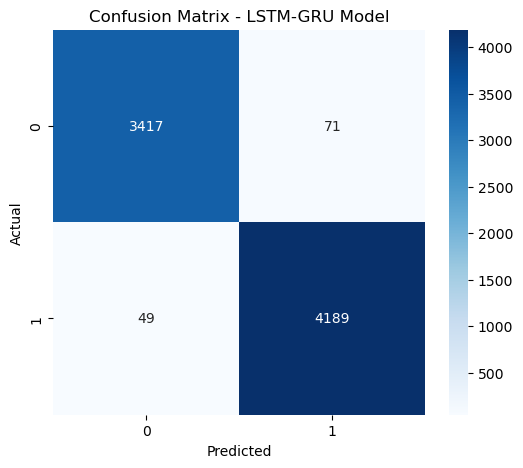

In [12]:
# Confusion Matrix Visualization
plt.figure(figsize=(6, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - LSTM-GRU Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [5]:
try:
    import empath  # noqa
except Exception:
    !pip install -q empath

try:
    import transformers  # noqa
except Exception:
    !pip install -q transformers

try:
    import torch  # noqa
except Exception:
    !pip install -q torch

try:
    import sklearn  # noqa
except Exception:
    !pip install -q scikit-learn
    
import os, re, numpy as np, pandas as pd, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report
from empath import Empath
from transformers import BertTokenizer, BertModel, get_linear_schedule_with_warmup

# Optional: set your text/label column names here if they differ
TEXT_COL = globals().get('TEXT_COL', 'text')
LABEL_COL = globals().get('LABEL_COL', 'sentiment')

# Only sanity-check df if it already exists
if 'df' in globals():
    if not {TEXT_COL, LABEL_COL}.issubset(set(df.columns)):
        raise AssertionError(
            f"Your df columns are {list(df.columns)} — expected TEXT_COL='{TEXT_COL}' , LABEL_COL='{LABEL_COL}'. "
            "Set TEXT_COL/LABEL_COL above or rename your columns."
        )
    else:
        print("✅ Imports OK. df has required columns.")
else:
    print("✅ Imports OK. No 'df' found yet — that's fine. Define df later and set TEXT_COL/LABEL_COL if needed.")


AssertionError: Your df columns are ['title', 'text', 'subject', 'date', 'real'] — expected TEXT_COL='text' , LABEL_COL='sentiment'. Set TEXT_COL/LABEL_COL above or rename your columns.

In [6]:
from empath import Empath
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Initialize Empath
lexicon = Empath()

# --- Custom categories for self-reference & cognitive complexity ---

SELF_REF_SEEDS = [
    "i", "me", "my", "mine", "myself",
    "we", "us", "our", "ours", "ourselves",
]

COG_COMPLEX_SEEDS = [
    # thinking / reasoning
    "think", "thought", "consider", "reason", "reflect", "wonder",
    # subordination / contrast / causation
    "because", "although", "though", "however", "but", "therefore",
    # hedging / uncertainty
    "maybe", "perhaps", "might", "could", "possibly", "apparently",
]

# Create custom Empath categories based on seed words
# (uses Empath's internal embedding space; no extra training step)
lexicon.create_category("self_reference", SELF_REF_SEEDS, model="reddit")
lexicon.create_category("cognitive_complexity", COG_COMPLEX_SEEDS, model="reddit")

# --- Requested categories (original + new ones) ---
REQUESTED_CATS = [
    "joy", "positive_emotion",
    "sadness", "anger", "negative_emotion",
    "social", "achievement", "affection", "violence", "disgust", "fear",
    # new features
    "self_reference",
    "cognitive_complexity",
]

# 1) Discover which requested categories are actually available
available = set()
try:
    probe = lexicon.analyze("test", categories=None, normalize=True)
    if isinstance(probe, dict):
        available = set(probe.keys())
except Exception as e:
    print("Empath probe error:", e)

if not available:
    raise RuntimeError(
        "Empath categories could not be discovered. "
        "This usually means the lexicon failed to load. "
        "Try: pip install --upgrade empath && restart the kernel."
    )

VALID_CATS = [c for c in REQUESTED_CATS if c in available]
print("Using Empath categories:", VALID_CATS)

# Export for helper functions in the wiring cell
EMPATH_CATS = VALID_CATS

# 2) Robust vectorizer
def empath_vector(text):
    txt = text if isinstance(text, str) else ""
    try:
        scores = lexicon.analyze(txt, categories=VALID_CATS, normalize=True)
        if not isinstance(scores, dict):
            scores = {}
    except Exception:
        scores = {}
    return [float(scores.get(c, 0.0)) for c in VALID_CATS]

# 3) Build matrix/dataframe (robust to NaNs)
texts = df['text'].astype(str).fillna("")
empath_list = texts.apply(empath_vector).tolist()
empath_matrix = np.asarray(empath_list, dtype=float)

empath_df = pd.DataFrame(empath_matrix, columns=[f"empath__{c}" for c in VALID_CATS])
df_empath = pd.concat([df.reset_index(drop=True), empath_df], axis=1)

# 4) Scale
scaler = StandardScaler()
E = scaler.fit_transform(df_empath.filter(like="empath__").to_numpy())

print("✅ Empath features shape:", E.shape)
print("✅ Added features: 'empath__self_reference' and 'empath__cognitive_complexity'")


⚠️ Unknown Empath categories (skipped): social
✅ Empath features shape: (38628, 10)


In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from collections import Counter

# 1) Pick the label column (your df shows 'real')
label_col = "real"
if label_col not in df_empath.columns:
    # Fallback to auto-detect if 'real' isn't there for some reason
    CANDIDATES = ["sentiment", "label", "labels", "target", "y", "category", "class", "real"]
    lower_map = {c.lower(): c for c in df_empath.columns}
    label_col = next((lower_map[c] for c in CANDIDATES if c in lower_map), None)
    if label_col is None:
        raise KeyError(f"No label column found. Available: {list(df_empath.columns)}")

print(f"Using label column: {label_col}")

# 2) Clean rows and keep alignment with E
text_series = df_empath["text"].astype(str)
label_series = df_empath[label_col]

mask = label_series.notna() & text_series.notna() & (text_series.str.len() > 0)
if not np.all(mask):
    print(f"⚠️ Dropping {(~mask).sum()} rows with missing/empty text or label.")

df_use = df_empath.loc[mask].reset_index(drop=True)
E_use = E[mask.to_numpy()]  # align Empath matrix

# 3) Encode labels if needed
if pd.api.types.is_bool_dtype(df_use[label_col]):
    y = df_use[label_col].astype(int).to_numpy()
    classes = np.unique(y)
    le = None
    print("Labels are boolean; converted to 0/1.")
elif pd.api.types.is_numeric_dtype(df_use[label_col]):
    y = df_use[label_col].to_numpy()
    classes = np.unique(y)
    le = None
    print("Labels are numeric; skipping LabelEncoder.")
else:
    le = LabelEncoder()
    y = le.fit_transform(df_use[label_col].astype(str))
    classes = le.classes_
    print("Classes mapping:", {cls: i for i, cls in enumerate(classes)})

num_classes = len(classes)
if num_classes < 2:
    raise ValueError(f"Need at least 2 classes; found {num_classes}.")

# 4) Decide if stratify is possible
counts = Counter(y)
can_stratify = all(v >= 2 for v in counts.values())
if not can_stratify:
    print("⚠️ Not stratifying due to classes with < 2 samples:", dict(counts))

# 5) Split
X_train_text, X_val_text, E_train, E_val, y_train, y_val = train_test_split(
    df_use["text"].tolist(),
    E_use,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y if can_stratify else None,
)

print(f"Train size: {len(X_train_text)} | Val size: {len(X_val_text)} | Classes: {num_classes}")



Using label column: real
Labels are numeric; skipping LabelEncoder.
Train size: 30902 | Val size: 7726 | Classes: 2


In [8]:
# 3) Tokenizer + Dataset
# import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel

TOKEN_MODEL = "bert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 16
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer = BertTokenizer.from_pretrained(TOKEN_MODEL)
bert_backbone = BertModel.from_pretrained(TOKEN_MODEL)

class HybridDataset(Dataset):
    def __init__(self, texts, empath_feats, labels, tokenizer, max_len=128):
        self.texts = texts
        self.empath = empath_feats
        self.labels = labels
        self.tok = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, i):
        enc = self.tok(
            self.texts[i],
            padding='max_length', truncation=True, max_length=self.max_len,
            return_tensors='pt'
        )
        item = {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "empath": torch.tensor(self.empath[i], dtype=torch.float32),
            "label": torch.tensor(self.labels[i], dtype=torch.long)
        }
        return item

train_ds = HybridDataset(X_train_text, E_train, y_train, tokenizer, MAX_LEN)
val_ds   = HybridDataset(X_val_text,   E_val,   y_val,   tokenizer, MAX_LEN)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print("✅ Datasets ready. Device:", DEVICE)


C:\Users\agmil\anaconda3\envs\dev\lib\site-packages\huggingface_hub\file_download.py:942: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\agmil\anaconda3\envs\dev\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\agmil\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

✅ Datasets ready. Device: cpu


In [9]:
# 4) Hybrid LSTM→GRU model (BERT sequence + Empath MLP)
class BERT_LIWC_LSTMGRU(nn.Module):
    def __init__(self, bert_model: BertModel, empath_dim: int, hidden_dim: int = 128, num_classes: int = 3, freeze_bert: bool = False):
        super().__init__()
        self.bert = bert_model
        if freeze_bert:
            for p in self.bert.parameters():
                p.requires_grad = False

        bert_dim = self.bert.config.hidden_size  # 768 for bert-base
        self.lstm = nn.LSTM(bert_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.gru  = nn.GRU(hidden_dim*2, hidden_dim, batch_first=True, bidirectional=True)

        self.empath_mlp = nn.Sequential(
            nn.Linear(empath_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim*2 + 64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, input_ids, attention_mask, empath_vec):
        # BERT: get token embeddings (last_hidden_state: [B, T, 768])
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        token_emb = out.last_hidden_state

        # LSTM -> GRU over token sequence
        lstm_out, _ = self.lstm(token_emb)      # [B, T, 2*H]
        gru_out, _  = self.gru(lstm_out)        # [B, T, 2*H]

        # Mean-pool over time
        pooled = gru_out.mean(dim=1)            # [B, 2*H]

        empath_feat = self.empath_mlp(empath_vec)        # [B, 64]
        fused = torch.cat([pooled, empath_feat], dim=1)  # [B, 2*H + 64]
        logits = self.fusion(fused)                      # [B, C]
        return logits

empath_dim = E_train.shape[1]
model = BERT_LIWC_LSTMGRU(bert_backbone, empath_dim=empath_dim, hidden_dim=128, num_classes=num_classes, freeze_bert=False)
model = model.to(DEVICE)
print("✅ Model ready.")

✅ Model ready.


In [ ]:
# 5) Train/evaluate loop
EPOCHS = 3
LR = 2e-5

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)
criterion = nn.CrossEntropyLoss()

def run_epoch(loader, train=True):
    model.train(train)
    total_loss, preds, gts = 0.0, [], []
    for batch in loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        empath_vec     = batch["empath"].to(DEVICE)
        labels         = batch["label"].to(DEVICE)

        with torch.set_grad_enabled(train):
            logits = model(input_ids, attention_mask, empath_vec)
            loss = criterion(logits, labels)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()

        total_loss += loss.item() * input_ids.size(0)
        preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy().tolist())
        gts.extend(labels.detach().cpu().numpy().tolist())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(preds), np.array(gts)

for epoch in range(1, EPOCHS+1):
    tr_loss, tr_pred, tr_gt = run_epoch(train_loader, train=True)
    va_loss, va_pred, va_gt = run_epoch(val_loader,   train=False)
    print(f"Epoch {epoch}/{EPOCHS} | train loss: {tr_loss:.4f} | val loss: {va_loss:.4f}")

print("Validation report:")
print(classification_report(va_gt, va_pred, target_names=list(le.classes_)))

In [ ]:
# 6) Inference helper (single text)
def predict_one(text: str):
    model.eval()
    with torch.no_grad():
        # Empath
        from numpy import array
        ev = np.array(empath_vector(text))[None, :]
        ev = scaler.transform(ev)
        ev_t = torch.tensor(ev, dtype=torch.float32, device=DEVICE)

        # BERT tokens
        enc = tokenizer(text, padding='max_length', truncation=True, max_length=MAX_LEN, return_tensors='pt')
        input_ids = enc['input_ids'].to(DEVICE)
        attn_mask = enc['attention_mask'].to(DEVICE)

        logits = model(input_ids, attn_mask, ev_t)
        pred_id = logits.argmax(dim=1).item()
        return le.classes_[pred_id]

print("Sample prediction:", predict_one("I absolutely loved this!"))

: 

: 

: 

: 

In [ ]:
# 5b) EarlyStopping + checkpointing and revised train/eval using it
import math, time
from dataclasses import dataclass

@dataclass
class ESConfig:
    patience: int = 3
    min_delta: float = 0.0
    path: str = "/mnt/data/best_hybrid_model.pt"
    verbose: bool = True

class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0, path="/mnt/data/best_hybrid_model.pt", verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.verbose = verbose
        self.best = math.inf
        self.wait = 0
        self.stopped_epoch = 0
        self.best_state = None

    def step(self, val_loss, model):
        improved = (self.best - val_loss) > self.min_delta
        if improved:
            self.best = val_loss
            self.wait = 0
            # Save best weights
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            torch.save(model.state_dict(), self.path)
            if self.verbose:
                print(f"  ↳ New best val loss {val_loss:.4f}. Saved checkpoint to {self.path}")
        else:
            self.wait += 1
            if self.verbose:
                print(f"  ↳ No improvement ({self.wait}/{self.patience})")
            if self.wait >= self.patience:
                self.stopped_epoch += 1
                return True  # should stop
        return False

# Revised train loop using EarlyStopping (replaces the previous loop)
def train_with_early_stopping(epochs=EPOCHS, es=ESConfig(), save_final_path="/mnt/data/final_hybrid_model.pt"):
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=int(0.1*total_steps), num_training_steps=total_steps)
    criterion = nn.CrossEntropyLoss()

    stopper = EarlyStopping(patience=es.patience, min_delta=es.min_delta, path=es.path, verbose=es.verbose)

    def run_epoch(loader, train=True):
        model.train(train)
        total_loss, preds, gts = 0.0, [], []
        for batch in loader:
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            empath_vec     = batch["empath"].to(DEVICE)
            labels         = batch["label"].to(DEVICE)

            with torch.set_grad_enabled(train):
                logits = model(input_ids, attention_mask, empath_vec)
                loss = criterion(logits, labels)
                if train:
                    optimizer.zero_grad()
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    scheduler.step()

            total_loss += loss.item() * input_ids.size(0)
            preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy().tolist())
            gts.extend(labels.detach().cpu().numpy().tolist())

        avg_loss = total_loss / len(loader.dataset)
        return avg_loss, np.array(preds), np.array(gts)

    best_report = None
    start_time = time.time()
    for epoch in range(1, epochs+1):
        tr_loss, tr_pred, tr_gt = run_epoch(train_loader, train=True)
        va_loss, va_pred, va_gt = run_epoch(val_loader,   train=False)
        print(f"Epoch {epoch}/{epochs} | train loss: {tr_loss:.4f} | val loss: {va_loss:.4f}")
        # Keep a report for the current epoch
        report = classification_report(va_gt, va_pred, target_names=list(le.classes_), zero_division=0)
        best_report = report if (va_loss <= (stopper.best if stopper.best < math.inf else va_loss)) else best_report

        # early stopping check
        should_stop = stopper.step(va_loss, model)
        if should_stop:
            print(f"⚠️ Early stopping at epoch {epoch}. Restoring best weights.")
            if stopper.best_state is not None:
                model.load_state_dict(stopper.best_state)
            break

    # Save final (possibly early-stopped) model
    torch.save(model.state_dict(), save_final_path)
    elapsed = time.time() - start_time
    print(f"Training complete in {elapsed/60:.1f} min. Best val loss: {stopper.best:.4f}")
    print("Validation report (best epoch candidate):")
    print(best_report if best_report is not None else "No report captured.")

# Example call (you can adjust patience/min_delta)
train_with_early_stopping(epochs=EPOCHS, es=ESConfig(patience=3, min_delta=0.0))

: 

: 

: 

: 

In [ ]:
# 3b) Wiring into existing dataloading code
# These helpers let you build the HybridDataset/DataLoaders from your existing DataFrames or lists,
# so you can re-use your current preprocessing/splits without rewriting them.

def build_empath_matrix_from_df(df_like, text_col='text', empath_cats=None, scaler_obj=None):
    cats = empath_cats or EMPATH_CATS
    def _vec(t):
        s = lexicon.analyze(t if isinstance(t, str) else "", categories=cats, normalize=True)
        return [s[c] for c in cats]
    M = np.vstack([_vec(x) for x in df_like[text_col].tolist()])
    if scaler_obj is None:
        scaler_local = StandardScaler().fit(M)
    else:
        scaler_local = scaler_obj
    return scaler_local.transform(M), scaler_local

def build_hybrid_loaders_from_df(train_df, val_df, text_col='text', label_col='sentiment',
                                 batch_size=16, max_len=128, tokenizer_obj=None, existing_label_encoder=None):
    # Empath
    E_tr, scaler_tr = build_empath_matrix_from_df(train_df, text_col=text_col, scaler_obj=None)
    E_va, _         = build_empath_matrix_from_df(val_df,   text_col=text_col, scaler_obj=scaler_tr)

    # Labels
    if existing_label_encoder is None:
        le_local = LabelEncoder().fit(train_df[label_col].values)
    else:
        le_local = existing_label_encoder
    y_tr = le_local.transform(train_df[label_col].values)
    y_va = le_local.transform(val_df[label_col].values)

    # Tokenizer
    tok = tokenizer_obj or tokenizer

    # Datasets
    ds_tr = HybridDataset(train_df[text_col].tolist(), E_tr, y_tr, tok, max_len=max_len)
    ds_va = HybridDataset(val_df[text_col].tolist(),   E_va, y_va, tok, max_len=max_len)

    # Loaders
    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    dl_va = DataLoader(ds_va, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return dl_tr, dl_va, le_local, scaler_tr

def build_hybrid_loaders_from_lists(train_texts, val_texts, y_train, y_val,
                                    batch_size=16, max_len=128, tokenizer_obj=None, scaler_obj=None):
    # Empath features
    def _vec(t):
        s = lexicon.analyze(t if isinstance(t, str) else "", categories=EMPATH_CATS, normalize=True)
        return [s[c] for c in EMPATH_CATS]
    E_tr = np.vstack([_vec(x) for x in train_texts])
    E_va = np.vstack([_vec(x) for x in val_texts])

    # Scale
    if scaler_obj is None:
        scaler_local = StandardScaler().fit(E_tr)
    else:
        scaler_local = scaler_obj
    E_tr = scaler_local.transform(E_tr)
    E_va = scaler_local.transform(E_va)

    # Tokenizer
    tok = tokenizer_obj or tokenizer

    # Datasets
    ds_tr = HybridDataset(train_texts, E_tr, y_train, tok, max_len=max_len)
    ds_va = HybridDataset(val_texts,   E_va, y_val,   tok, max_len=max_len)

    # Loaders
    dl_tr = DataLoader(ds_tr, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    dl_va = DataLoader(ds_va, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    return dl_tr, dl_va, scaler_local

print("""✅ Wiring helpers added.

Examples:
1) If you already have train_df/val_df with 'text' and 'sentiment':
   train_loader, val_loader, le, scaler = build_hybrid_loaders_from_df(train_df, val_df)

2) If you have lists (X_train_text, X_val_text, y_train, y_val):
   train_loader, val_loader, scaler = build_hybrid_loaders_from_lists(X_train_text, X_val_text, y_train, y_val)

After building loaders, you can re-create the model and run:
   empath_dim = next(iter(train_loader))['empath'].shape[1]
   model = BERT_LIWC_LSTMGRU(bert_backbone, empath_dim=empath_dim, hidden_dim=128, num_classes=num_classes).to(DEVICE)
   train_with_early_stopping(epochs=EPOCHS, es=ESConfig(patience=3))
""")

: 

: 

: 

: 

In [ ]:
# ============================================
# Ablation: self_reference & cognitive_complexity
# ============================================

import numpy as np
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report

device = DEVICE  # reuse existing DEVICE

# --- 1) Identify Empath columns and build masks ---
empath_cols = df_empath.filter(like="empath__").columns.tolist()

ABLATE_COLS = ["empath__self_reference", "empath__cognitive_complexity"]

keep_indices = [i for i, c in enumerate(empath_cols) if c not in ABLATE_COLS]
drop_indices = [i for i, c in enumerate(empath_cols) if c in ABLATE_COLS]

print("All Empath dims:", len(empath_cols))
print("Dropping:", [empath_cols[i] for i in drop_indices])
print("Keeping:", len(keep_indices), "dims")

E_train_full = E_train
E_val_full   = E_val

E_train_ablate = E_train_full[:, keep_indices]
E_val_ablate   = E_val_full[:, keep_indices]

print("Full E_train shape:", E_train_full.shape)
print("Ablated E_train shape:", E_train_ablate.shape)

# --- 2) Helper to build loaders for a given empath matrix ---

def build_loaders_with_empath(E_train_mat, E_val_mat, batch_size=BATCH_SIZE, shuffle_train=True):
    """Rebuild HybridDataset/DataLoaders using alternative Empath features."""
    # Uses existing X_train_text, X_val_text, y_train, y_val, tokenizer, MAX_LEN
    train_ds_alt = HybridDataset(X_train_text, E_train_mat, y_train, tokenizer, MAX_LEN)
    val_ds_alt   = HybridDataset(X_val_text,   E_val_mat,   y_val,   tokenizer, MAX_LEN)

    train_loader_alt = DataLoader(train_ds_alt, batch_size=batch_size, shuffle=shuffle_train, num_workers=2, pin_memory=True)
    val_loader_alt   = DataLoader(val_ds_alt,   batch_size=batch_size, shuffle=False,       num_workers=2, pin_memory=True)
    return train_loader_alt, val_loader_alt

train_loader_full,   val_loader_full   = build_loaders_with_empath(E_train_full,   E_val_full)
train_loader_ablate, val_loader_ablate = build_loaders_with_empath(E_train_ablate, E_val_ablate)

# --- 3) Training / evaluation helper ---

def train_and_eval(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, run_name="run"):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )
    criterion_local = nn.CrossEntropyLoss()

    def _run_epoch(loader, train=True):
        if train:
            model.train()
        else:
            model.eval()
        total_loss, preds, gts = 0.0, [], []
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            empath_vec     = batch["empath"].to(device)
            labels         = batch["label"].to(device)

            with torch.set_grad_enabled(train):
                logits = model(input_ids, attention_mask, empath_vec)
                loss   = criterion_local(logits, labels)

                if train:
                    optimizer.zero_grad()
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    optimizer.step()
                    scheduler.step()

            total_loss += loss.item() * input_ids.size(0)
            preds.extend(torch.argmax(logits, dim=1).detach().cpu().numpy().tolist())
            gts.extend(labels.detach().cpu().numpy().tolist())

        avg_loss = total_loss / len(loader.dataset)
        return avg_loss, np.array(preds), np.array(gts)

    for epoch in range(1, epochs + 1):
        tr_loss, tr_pred, tr_gt = _run_epoch(train_loader, train=True)
        va_loss, va_pred, va_gt = _run_epoch(val_loader,   train=False)
        print(f"[{run_name}] Epoch {epoch}/{epochs} | train loss: {tr_loss:.4f} | val loss: {va_loss:.4f}")

    acc = accuracy_score(va_gt, va_pred)
    print(f"[{run_name}] Validation accuracy: {acc:.4f}")
    print(f"[{run_name}] Classification report:")
    print(classification_report(va_gt, va_pred, digits=4))

    return {
        "val_loss": va_loss,
        "val_accuracy": acc,
        "y_true": va_gt,
        "y_pred": va_pred,
    }

# --- 4) Run experiments ---

empath_dim_full   = E_train_full.shape[1]
empath_dim_ablate = E_train_ablate.shape[1]

# FULL model
model_full = BERT_LIWC_LSTMGRU(
    bert_backbone,
    empath_dim=empath_dim_full,
    hidden_dim=128,
    num_classes=num_classes,
    freeze_bert=False,
).to(device)

metrics_full = train_and_eval(
    model_full,
    train_loader_full,
    val_loader_full,
    epochs=EPOCHS,
    lr=LR,
    run_name="FULL_empath",
)

# Ablated model (without self_reference & cognitive_complexity)
model_ablate = BERT_LIWC_LSTMGRU(
    bert_backbone,
    empath_dim=empath_dim_ablate,
    hidden_dim=128,
    num_classes=num_classes,
    freeze_bert=False,
).to(device)

metrics_ablate = train_and_eval(
    model_ablate,
    train_loader_ablate,
    val_loader_ablate,
    epochs=EPOCHS,
    lr=LR,
    run_name="ABLATE_selfref_cogcomplex",
)

# --- 5) Side-by-side summary ---

print("\n===== ABLATION SUMMARY (Validation Accuracy) =====")
print(f"FULL_empath accuracy:            {metrics_full['val_accuracy']:.4f}")
print(f"ABLATE_selfref_cogcomplex:       {metrics_ablate['val_accuracy']:.4f}")
print("==================================================")


In [ ]:
# ============================================
# Detailed evaluation: FULL vs ABLATE models
# ============================================

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

def collect_predictions(model, data_loader):
    """Run model on data_loader and collect y_true, y_pred."""
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in data_loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            empath_vec     = batch["empath"].to(device)
            labels         = batch["label"].to(device)

            logits = model(input_ids, attention_mask, empath_vec)
            preds  = torch.argmax(logits, dim=-1)

            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    y_pred = np.concatenate(all_preds)
    y_true = np.concatenate(all_labels)
    return y_true, y_pred

def evaluate_model_detailed(model, loader, run_name="model"):
    print(f"\n========== {run_name}: Detailed Evaluation ==========")
    y_true, y_pred = collect_predictions(model, loader)

    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc:.4f}\n")

    print("Classification report:")
    print(classification_report(y_true, y_pred, digits=4))

    cm = confusion_matrix(y_true, y_pred)
    print("Confusion matrix (rows = true, cols = pred):")
    print(cm)

    return {
        "accuracy": acc,
        "y_true": y_true,
        "y_pred": y_pred,
        "confusion_matrix": cm,
    }

full_eval   = evaluate_model_detailed(model_full,   val_loader_full,   run_name="FULL_empath")
ablate_eval = evaluate_model_detailed(model_ablate, val_loader_ablate, run_name="ABLATE_selfref_cogcomplex")

print("\n===== SUMMARY: Accuracy Comparison =====")
print(f"FULL_empath accuracy:      {full_eval['accuracy']:.4f}")
print(f"ABLATE_selfref_cogcomplex: {ablate_eval['accuracy']:.4f}")
print("========================================")
